<a href="https://colab.research.google.com/github/musowjanya/Deep-Learning/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader

In [102]:
dataset = datasets.MNIST(root='./data', train=True, download=True,
                         transform=transforms.ToTensor())

In [103]:
x_train = dataset.data
y_train = dataset.targets

In [104]:
selected_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
x_final, y_final = [], []

In [105]:
for cls in selected_classes:
    indices = (y_train == cls).nonzero(as_tuple=True)[0][:100]
    x_final.append(x_train[indices])
    y_final.append(y_train[indices])


In [106]:
xx = torch.cat(x_final)   # (300, 28, 28)
yy = torch.cat(y_final)

In [107]:
xx = xx.float() / 255.0

In [108]:
dataset = TensorDataset(xx, yy)
data = DataLoader(dataset, batch_size=32, shuffle=True)

In [109]:
import torch.nn as nn

class DeepNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)   # output layer (10 classes)
        )

    def forward(self, x):
        return self.model(x)

model = DeepNN()

In [110]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [111]:
model.train()
for epoch in range(150):
    total_loss = 0

    for xb, yb in data:
        outputs = model(xb)
        loss = loss_fn(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 62.5447
Epoch 2, Loss: 27.1722
Epoch 3, Loss: 16.9696
Epoch 4, Loss: 11.4746
Epoch 5, Loss: 9.2725
Epoch 6, Loss: 7.3373
Epoch 7, Loss: 5.2957
Epoch 8, Loss: 4.6561
Epoch 9, Loss: 4.6171
Epoch 10, Loss: 2.4181
Epoch 11, Loss: 1.5578
Epoch 12, Loss: 1.0383
Epoch 13, Loss: 0.7685
Epoch 14, Loss: 0.6887
Epoch 15, Loss: 0.4558
Epoch 16, Loss: 0.4017
Epoch 17, Loss: 0.3371
Epoch 18, Loss: 0.2929
Epoch 19, Loss: 0.1971
Epoch 20, Loss: 0.1682
Epoch 21, Loss: 0.1427
Epoch 22, Loss: 0.1236
Epoch 23, Loss: 0.1148
Epoch 24, Loss: 0.0955
Epoch 25, Loss: 0.0859
Epoch 26, Loss: 0.0776
Epoch 27, Loss: 0.0719
Epoch 28, Loss: 0.0649
Epoch 29, Loss: 0.0575
Epoch 30, Loss: 0.0532
Epoch 31, Loss: 0.0526
Epoch 32, Loss: 0.0461
Epoch 33, Loss: 0.0422
Epoch 34, Loss: 0.0393
Epoch 35, Loss: 0.0367
Epoch 36, Loss: 0.0356
Epoch 37, Loss: 0.0322
Epoch 38, Loss: 0.0299
Epoch 39, Loss: 0.0290
Epoch 40, Loss: 0.0272
Epoch 41, Loss: 0.0264
Epoch 42, Loss: 0.0245
Epoch 43, Loss: 0.0222
Epoch 44, Loss: 

In [112]:
# model(x_train)

In [113]:
import cv2

In [114]:
ar=cv2.imread('/content/two new.png')

In [115]:
ar.shape

(512, 512, 3)

In [116]:
grar=cv2.cvtColor(ar,cv2.COLOR_BGR2GRAY)

In [117]:
rszar=cv2.resize(grar,(28,28))

In [118]:
far=rszar.reshape(1,1,28,28)

In [119]:
far

array([[[[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 126, 126,
          126, 126, 126, 126, 126, 126,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0, 126, 126, 126,
          126, 126, 126, 126, 126, 126, 126, 124,   0,   0,   0,   0,
            0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0, 126, 126, 126, 126,
          126, 126, 126, 126, 126, 126, 126, 126,   0,   0,   0,   0,
     

In [120]:
import matplotlib.pyplot as plt

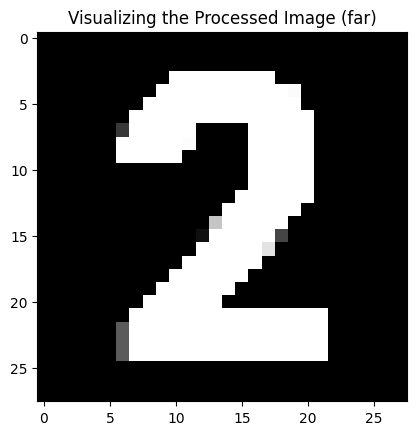

In [121]:
plt.imshow(far.squeeze(), cmap='gray')
plt.title('Visualizing the Processed Image (far)')
plt.show()

In [122]:
fimg = torch.from_numpy(far).float()
print(f"Shape of fimg before model call: {fimg.shape}")

Shape of fimg before model call: torch.Size([1, 1, 28, 28])


In [123]:
model(fimg)

tensor([[-1986.7606, -2602.3704,  3992.3691,  1733.4019, -6584.0884, -2227.2158,
         -3227.5149,  -853.1707,  -686.9645,  -942.7307]],
       grad_fn=<AddmmBackward0>)

In [124]:
sfx=torch.softmax(model(fimg),dim=1)

In [125]:
torch.argmax(sfx,dim=1)

tensor([2])